In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ------------------------------------------------------------------
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ------------------------------------------------------------------
def load_and_preprocess(file_path):
    """Загрузка и предобработка данных"""
    df = pd.read_excel(file_path)
    df = df.drop_duplicates()

    # Создание unique_id
    df["unique_id"] = (
        df["id"].astype(str) + "_" +
        df["Код филиала"].astype(str) + "_" +
        df["Код ЦФО"].astype(str)
    )

    df_both = df[df["Показатель"].isin(["ДЗ н.п.", "ДЗ к.п."])]

    # Преобразование в длинный формат
    id_vars = ["id", "Код филиала", "Код ЦФО", "Показатель", "number", "unique_id"]
    df_long = pd.melt(df_both, id_vars=id_vars, var_name="month", value_name="y")

    # Функция для корректного создания дат
    def get_date(row):
        month_num = int(row['month'])
        if month_num <= 12:
            year, month = 2022, month_num
        else:
            year, month = 2023, month_num - 12

        if row['Показатель'] == 'ДЗ н.п.':
            return pd.Timestamp(f"{year}-{month:02d}-01")
        else:
            if month == 12:
                next_year, next_month = year + 1, 1
            else:
                next_year, next_month = year, month + 1
            next_month_start = pd.Timestamp(f"{next_year}-{next_month:02d}-01")
            return next_month_start - pd.Timedelta(days=1)

    df_long['ds'] = df_long.apply(get_date, axis=1)

    # Фильтрация нулевых рядов
    mask = df_long.groupby("unique_id")["y"].transform("sum") != 0
    df_long = df_long[mask].sort_values(["unique_id", "ds"])

    df_start = df_long[df_long['Показатель'] == 'ДЗ н.п.'].copy()
    df_end = df_long[df_long['Показатель'] == 'ДЗ к.п.'].copy()
    df_end['ds'] = df_end['ds'] + pd.offsets.MonthBegin(1)
    df_combined = pd.concat([df_start, df_end], ignore_index=True)
    df_combined = df_combined.sort_values(['unique_id', 'ds'])
    df_combined = df_combined.drop_duplicates(subset=['unique_id', 'ds'], keep='first')

    return df_combined[['unique_id', 'y', 'ds']]

In [3]:
# ------------------------------------------------------------------
# 2. ОБЗОР ДАННЫХ
# ------------------------------------------------------------------
df_combined = load_and_preprocess('data.xlsx')


print("Размер:", df_combined.shape)
print("Типы данных:\n", df_combined.dtypes)
print("Статистики:\n", df_combined['y'].describe())
print("Количество уникальных рядов:", df_combined['unique_id'].nunique())
print("Диапазон дат:", df_combined['ds'].min(), "—", df_combined['ds'].max())
print("Пропуски в y:", df_combined['y'].isna().sum())

Размер: (35775, 3)
Типы данных:
 unique_id            object
y                   float64
ds           datetime64[ns]
dtype: object
Статистики:
 count    3.577500e+04
mean     1.174954e+07
std      1.149765e+08
min     -1.240568e+07
25%      0.000000e+00
50%      1.849016e+04
75%      6.598726e+05
max      6.386330e+09
Name: y, dtype: float64
Количество уникальных рядов: 1431
Диапазон дат: 2022-01-01 00:00:00 — 2024-01-01 00:00:00
Пропуски в y: 0


Распределение длины рядов:
 count    1431.0
mean       25.0
std         0.0
min        25.0
25%        25.0
50%        25.0
75%        25.0
max        25.0
Name: y, dtype: float64


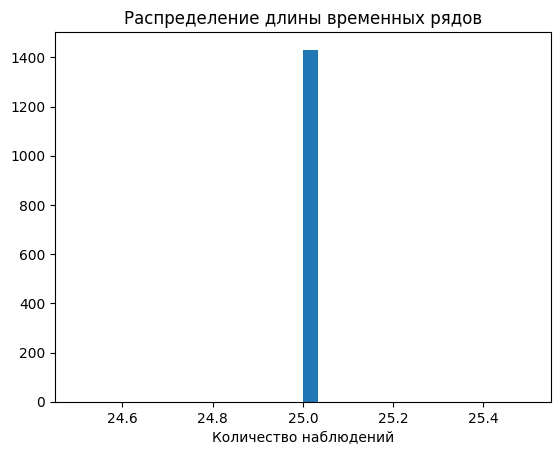

Ряды с пропусками: Series([], Name: y, dtype: int64)


In [4]:
# ------------------------------------------------------------------
# 3. АНАЛИЗ ПРОПУСКОВ И ДЛИНЫ РЯДОВ
# ------------------------------------------------------------------

# Длина каждого ряда
lengths = df_combined.groupby('unique_id')['y'].count()
print("Распределение длины рядов:\n", lengths.describe())
# Гистограмма длин
plt.hist(lengths, bins=30)
plt.title('Распределение длины временных рядов')
plt.xlabel('Количество наблюдений')
plt.show()

# Пропуски в каждом ряду (если есть)
missing = df_combined.isna().groupby('unique_id')['y'].sum()
print("Ряды с пропусками:", missing[missing > 0])

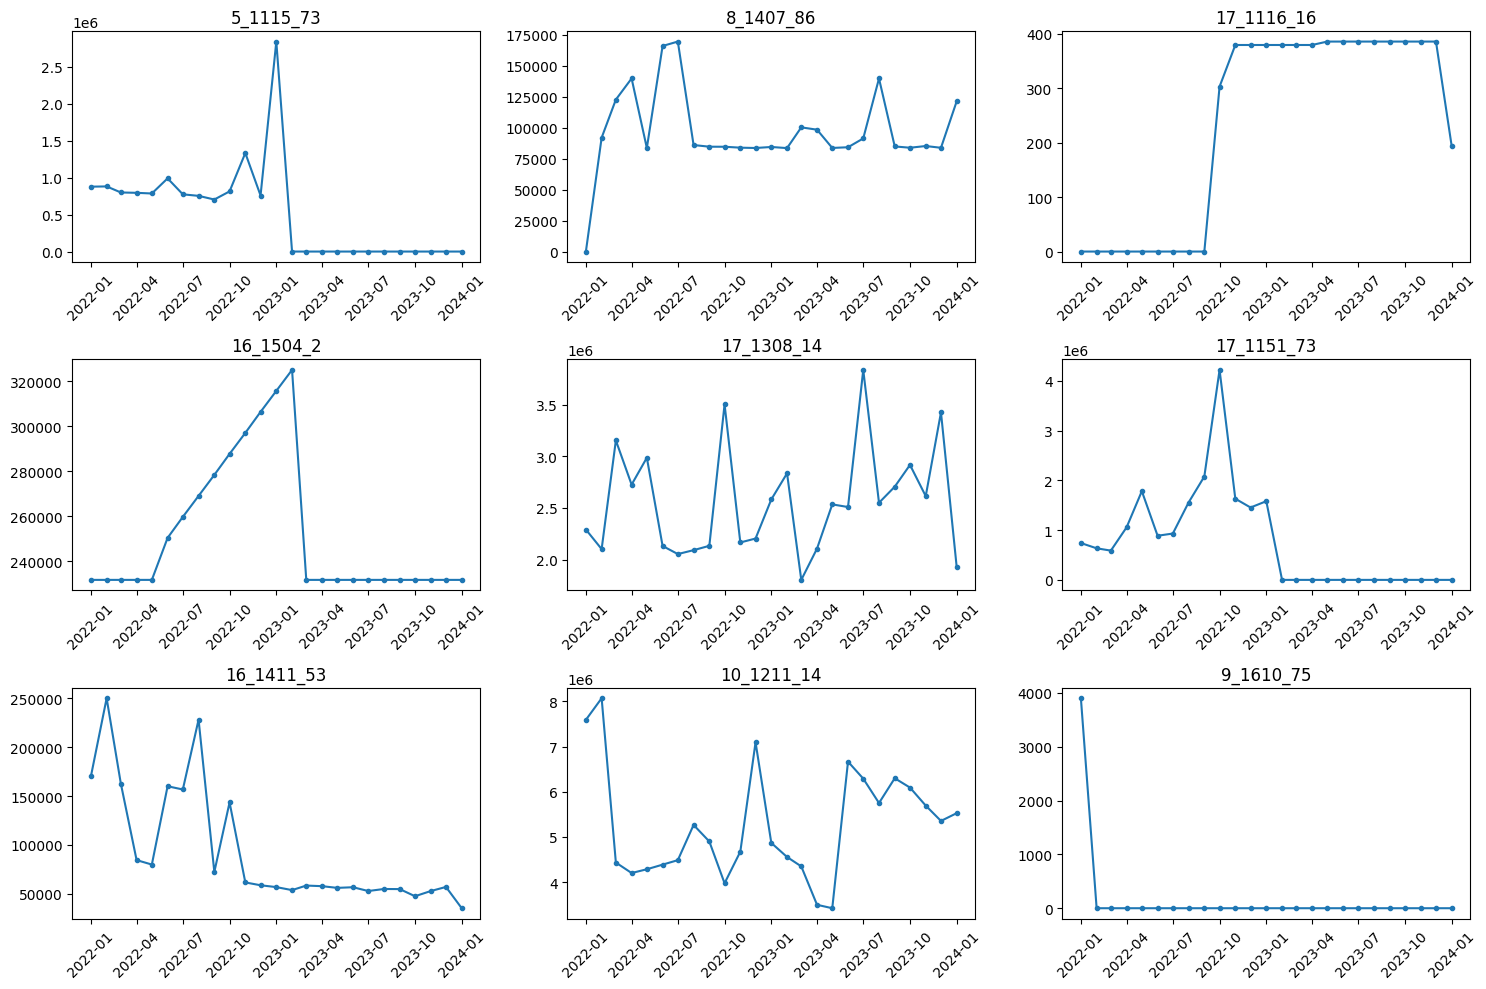

In [5]:
# ------------------------------------------------------------------
# 4. ПРИМЕРЫ ВИЗУАЛИЗАЦИИ
# ------------------------------------------------------------------

sample_ids = df_combined['unique_id'].sample(9, random_state=42)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, sid in zip(axes.flat, sample_ids):
    series = df_combined[df_combined['unique_id'] == sid].sort_values('ds')
    ax.plot(series['ds'], series['y'], marker='.', linestyle='-')
    ax.set_title(sid[:20])
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------------
# 5. АНАЛИЗ СТАЦИОНАРНОСТИ
# ------------------------------------------------------------------

from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def test_stationarity(df_long, unique_id_col='unique_id', ds_col='ds', y_col='y', alpha_adf=0.05, alpha_kpss=0.05):
    results = []

    grouped = df_long.groupby(unique_id_col)

    for series_id, group_df in grouped:
        group_df = group_df.sort_values(by=ds_col)
        ts = group_df[y_col].values

        ts = ts[~np.isnan(ts)]

        if len(ts) < 5:
            results.append({
                'unique_id': series_id,
                'length': len(ts),
                'adf_stat': np.nan,
                'adf_pvalue': np.nan,
                'adf_lags': np.nan,
                'kpss_stat': np.nan,
                'kpss_pvalue': np.nan,
                'kpss_lags': np.nan,
                'is_stationary': None,
                'decision': 'too_short'
            })
            continue

        # --- ADF тест ---
        try:
            maxlag_adf = min(int(np.ceil(12 * (len(ts)/100)**(1/4))), len(ts)//2 - 1)
            adf_res = adfuller(ts, autolag='AIC', maxlag=max(1, maxlag_adf))
            #adf_res = adfuller(ts, regression='ct', autolag='AIC', maxlag=max(1, maxlag_adf))
            adf_stat, adf_pval, adf_lags, _, _, _ = adf_res
        except Exception as e:
            adf_stat, adf_pval, adf_lags = np.nan, np.nan, np.nan

        # --- KPSS тест ---
        try:
            kpss_res = kpss(ts, regression='c', nlags='auto')
            #kpss_res = kpss(ts, regression='ct', nlags='auto')
            kpss_stat, kpss_pval, kpss_lags, _ = kpss_res
        except Exception as e:
            kpss_stat, kpss_pval, kpss_lags = np.nan, np.nan, np.nan

        adf_reject = adf_pval <= alpha_adf if not np.isnan(adf_pval) else False
        kpss_reject = kpss_pval <= alpha_kpss if not np.isnan(kpss_pval) else False

        if adf_reject and not kpss_reject:
            decision = 'stationary'
        elif not adf_reject and kpss_reject:
            decision = 'non_stationary'
        elif adf_reject and kpss_reject:
            decision = 'ambiguous'
        elif not adf_reject and not kpss_reject:
            decision = 'low_power'
        else:
            decision = 'error'

        results.append({
            'unique_id': series_id,
            'length': len(ts),
            'adf_stat': adf_stat,
            'adf_pvalue': adf_pval,
            'adf_lags': adf_lags,
            'kpss_stat': kpss_stat,
            'kpss_pvalue': kpss_pval,
            'kpss_lags': kpss_lags,
            'is_stationary': decision == 'stationary',
            'decision': decision
        })

    return pd.DataFrame(results)



decision
low_power         469
non_stationary    459
stationary        403
ambiguous         100
Name: count, dtype: int64


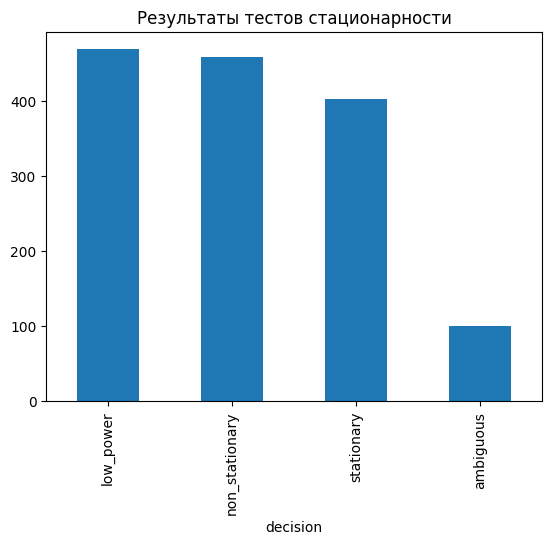

Нестационарных рядов: 459


In [7]:
results = test_stationarity(df_combined)
print(results['decision'].value_counts())
results['decision'].value_counts().plot(kind='bar')
plt.title('Результаты тестов стационарности')
plt.show()

non_stat = results[results['decision'] == 'non_stationary']['unique_id'].tolist()
print(f"Нестационарных рядов: {len(non_stat)}")

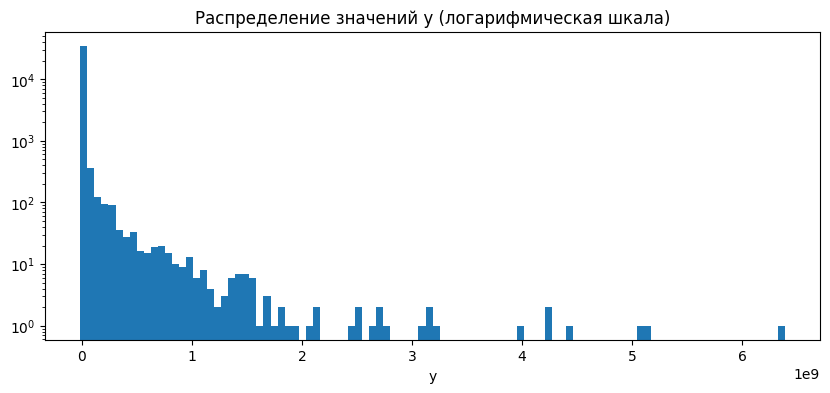

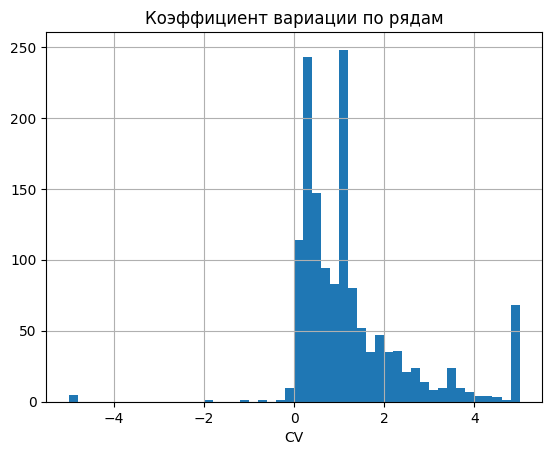

In [9]:
# ------------------------------------------------------------------
# 6. АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗНАЧЕНИЙ
# ------------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.hist(df_combined['y'], bins=100, log=True)
plt.title('Распределение значений y (логарифмическая шкала)')
plt.xlabel('y')
plt.show()

# По каждому ряду — коэффициенты вариации
cv = df_combined.groupby('unique_id')['y'].apply(lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan)
cv.hist(bins=50)
plt.title('Коэффициент вариации по рядам')
plt.xlabel('CV')
plt.show()

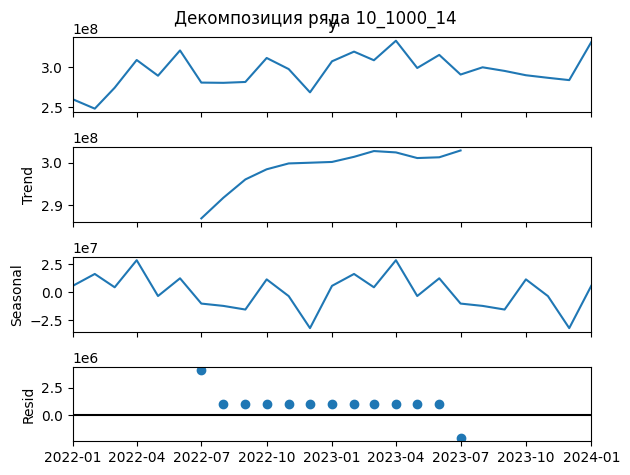

In [10]:
# ------------------------------------------------------------------
# 7. ТРЕНД И СЕЗОННОСТЬ (ПРИМЕР)
# ------------------------------------------------------------------
long_ids = lengths[lengths >= 24].index.tolist()
if long_ids:
    sid = long_ids[0]
    series = df_combined[df_combined['unique_id'] == sid].sort_values('ds')
    series.set_index('ds', inplace=True)
    series = series.asfreq('MS')
    # Декомпозиция
    try:
        decomp = seasonal_decompose(series['y'], model='additive', period=12)
        decomp.plot()
        plt.suptitle(f'Декомпозиция ряда {sid}')
        plt.show()
    except Exception as e:
        print(f"Ошибка декомпозиции: {e}")

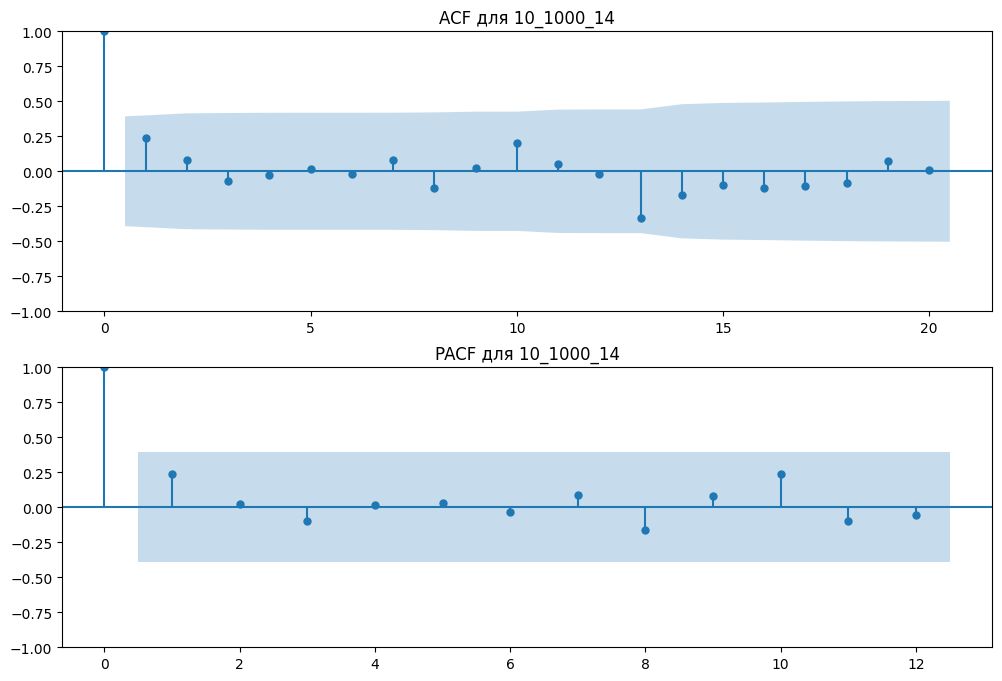

In [11]:
# ------------------------------------------------------------------
# 8. АВТОКОРРЕЛЯЦИОННЫЙ АНАЛИЗ (пример)
# ------------------------------------------------------------------
# Для того же ряда
if long_ids:
    series = df_combined[df_combined['unique_id'] == sid].sort_values('ds')
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
    plot_acf(series['y'], lags=20, ax=ax1)
    plot_pacf(series['y'], lags=12, ax=ax2)
    ax1.set_title(f'ACF для {sid}')
    ax2.set_title(f'PACF для {sid}')
    plt.show()

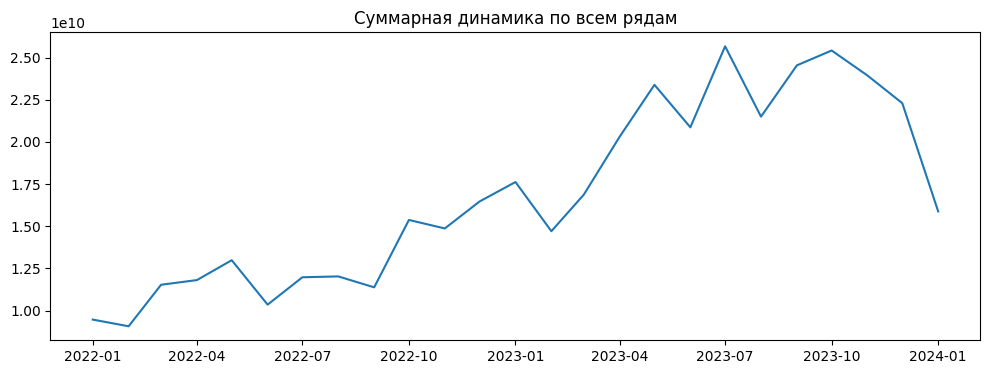

In [12]:
# ------------------------------------------------------------------
# 9. АГРЕГИРОВАННЫЙ АНАЛИЗ
# ------------------------------------------------------------------
monthly_agg = df_combined.groupby('ds')['y'].sum()
plt.figure(figsize=(12,4))
plt.plot(monthly_agg.index, monthly_agg.values)
plt.title('Суммарная динамика по всем рядам')
plt.show()

In [13]:
# ------------------------------------------------------------------
# 10. КРАТКИЙ ОТЧЕТ
# ------------------------------------------------------------------
report = pd.DataFrame()
report['length'] = lengths
report['mean'] = df_combined.groupby('unique_id')['y'].mean()
report['std'] = df_combined.groupby('unique_id')['y'].std()
report['cv'] = report['std'] / report['mean'].replace(0, np.nan)
report['min'] = df_combined.groupby('unique_id')['y'].min()
report['max'] = df_combined.groupby('unique_id')['y'].max()
# + результаты стационарности
report = report.join(results.set_index('unique_id')[['decision']])
report.to_csv('series_eda_report.csv')
print("Отчет сохранен.")

Отчет сохранен.


In [14]:
report

,length,mean,std,cv,min,max,decision
unique_id,,,,,,,
10_1000_14,25,2.948131e+08,2.090698e+07,0.070916,2.481821e+08,3.321647e+08,stationary
10_1100_14,25,4.885849e+07,7.008069e+06,0.143436,3.637777e+07,6.649634e+07,low_power
10_1101_14,25,2.634681e+05,2.105212e+05,0.799039,8.512576e+04,6.954746e+05,ambiguous
10_1101_16,25,1.432783e+03,8.646879e+02,0.603502,9.575502e+02,3.300626e+03,low_power
10_1102_14,25,3.311113e+04,4.169636e+04,1.259285,3.081244e+03,1.389356e+05,ambiguous
...,...,...,...,...,...,...,...
9_1215_53,25,1.710859e+03,3.832808e+03,2.240283,0.000000e+00,1.665508e+04,ambiguous
9_1407_53,25,3.200825e+03,4.001031e+03,1.250000,0.000000e+00,8.002063e+03,non_stationary
9_1504_53,25,1.773041e+01,5.893934e+01,3.324194,0.000000e+00,2.670351e+02,low_power
